## Implementing simple chatbot using langGraph

In [10]:
from typing import TypedDict, Annotated
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langchain_groq import ChatGroq
from IPython.display import Image

In [3]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ['GROQ_API_KEY'] = os.getenv('GROQ_API_KEY')

In [7]:
llm = ChatGroq(model="llama-3.3-70b-versatile")

In [8]:
llm.invoke("what is machine learning")

AIMessage(content="**Machine Learning: A Comprehensive Overview**\n=====================================================\n\nMachine learning is a subset of artificial intelligence (AI) that involves the use of algorithms and statistical models to enable machines to perform tasks without being explicitly programmed. It is a type of computational learning that allows systems to automatically improve their performance on a task based on experience.\n\n**Key Characteristics of Machine Learning:**\n\n1. **Data-Driven**: Machine learning relies on data to learn and make predictions or decisions.\n2. **Algorithmic**: Machine learning uses algorithms to analyze data and make predictions or decisions.\n3. **Self-Improving**: Machine learning systems can improve their performance over time through experience and learning.\n4. **Non-Programmatic**: Machine learning systems can perform tasks without being explicitly programmed.\n\n**Types of Machine Learning:**\n\n1. **Supervised Learning**: The s

In [6]:
class State(TypedDict):
    messages: Annotated[list, add_messages]

### Create Nodes

In [9]:
def superbot(state: State):
    return {"messages": [llm.invoke(state['messages'])]}

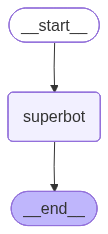

In [ ]:
# build Graph
graph = StateGraph(State)

# Add nodes
graph.add_node("superbot", superbot)

# add edge
graph.add_edge(START, "superbot")
graph.add_edge("superbot", END)

# compile the graph
graph_builder = graph.compile()

# display the graph
Image(graph_builder.get_graph().draw_mermaid_png())

In [12]:
graph_builder.invoke({"messages": "what is machine learning?"})

{'messages': [HumanMessage(content='what is machine learning?', additional_kwargs={}, response_metadata={}, id='b45e11b6-821b-42d2-888e-ab8b4156968a'),
  AIMessage(content='**Machine Learning Definition**\n\nMachine learning (ML) is a subset of artificial intelligence (AI) that involves the use of algorithms and statistical models to enable machines to perform tasks without being explicitly programmed. It allows systems to learn from data, identify patterns, and make predictions or decisions with minimal human intervention.\n\n**Key Characteristics of Machine Learning:**\n\n1. **Data-driven**: Machine learning relies on large amounts of data to train and improve models.\n2. **Self-improvement**: ML models can learn from experience and adapt to new data.\n3. **Pattern recognition**: ML algorithms can identify complex patterns in data.\n4. **Prediction**: ML models can make predictions or decisions based on learned patterns.\n\n**Types of Machine Learning:**\n\n1. **Supervised Learning**

In [15]:
for even in graph_builder.stream({'messages': "what is deep learning"}, stream_mode="values"):
    print(even)
    

{'messages': [HumanMessage(content='what is deep learning', additional_kwargs={}, response_metadata={}, id='2b0c0fb3-eca1-47dd-9f4c-2aef536150b2')]}
{'messages': [HumanMessage(content='what is deep learning', additional_kwargs={}, response_metadata={}, id='2b0c0fb3-eca1-47dd-9f4c-2aef536150b2'), AIMessage(content='Deep learning is a subset of machine learning, which is a field of artificial intelligence (AI) that involves the use of algorithms to analyze data and make predictions or decisions. Deep learning is characterized by the use of neural networks with multiple layers, which are modeled after the structure and function of the human brain.\n\n**Key Features of Deep Learning:**\n\n1. **Neural Networks**: Deep learning uses neural networks, which are composed of multiple layers of interconnected nodes (neurons) that process and transmit information.\n2. **Multiple Layers**: Deep learning models have multiple layers, which allow them to learn complex patterns and relationships in dat

In [16]:
for even in graph_builder.stream({'messages': "what is deep learning"}, stream_mode="updates"):
    print(even)
    

{'superbot': {'messages': [AIMessage(content='**Deep Learning: An Overview**\n=====================================\n\nDeep learning is a subset of machine learning that involves the use of artificial neural networks to analyze and interpret data. These neural networks are designed to mimic the structure and function of the human brain, with multiple layers of interconnected nodes (neurons) that process and transmit information.\n\n**Key Characteristics of Deep Learning:**\n\n1. **Artificial Neural Networks**: Deep learning models are based on artificial neural networks, which are composed of multiple layers of nodes (neurons) that process and transmit information.\n2. **Multiple Layers**: Deep learning models typically have multiple layers, with each layer learning to represent the data in a different way.\n3. **Hierarchical Representation**: Deep learning models learn to represent data in a hierarchical manner, with early layers learning to recognize simple features and later layers 